In [1]:
# Cell 1: Imports and setup

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful")

# Setup paths (same logic as other notebooks)
current_path = Path.cwd()

if (current_path / "data").exists():
    BASE_DIR = current_path
else:
    BASE_DIR = current_path.parent

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = BASE_DIR / "figures"

# Create figures directory
FIGURES_DIR.mkdir(exist_ok=True)

print(f"\nDirectories configured:")
print(f"  Project root: {BASE_DIR}")
print(f"  Data: {DATA_DIR}")
print(f"  Processed: {PROCESSED_DIR}")
print(f"  Figures: {FIGURES_DIR}")


All imports successful

Directories configured:
  Project root: /Users/tanishbhilare/Desktop/SoccerImpectHackathon
  Data: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/data
  Processed: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/data/processed
  Figures: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures


In [2]:
# Cell 2: Load final data

print("Loading final processed data")

# Load player ratings from Notebook 4
try:
    # First try: 8-metric system with market values (from Notebook 4)
    player_final = pl.read_parquet(PROCESSED_DIR / "player_ratings_with_8_metrics.parquet")
    print(f"Loaded {len(player_final)} players with 8-metric ratings")
except FileNotFoundError:
    # Fallback: 3-metric system from Notebook 2
    player_final = pl.read_parquet(PROCESSED_DIR / "player_ratings_final.parquet")
    print(f"Loaded {len(player_final)} players with 3-metric ratings")

# Load events for validation
all_events = pl.read_parquet(PROCESSED_DIR / "all_matches_with_zones.parquet")
print(f"Loaded {len(all_events):,} events")

# Display dataset summary
print(f"\nDataset summary:")
print(f"  Total players: {len(player_final)}")
print(f"  Forwards: {(player_final['position'] == 'forward').sum()}")
print(f"  Midfielders: {(player_final['position'] == 'midfielder').sum()}")
print(f"  Defenders: {(player_final['position'] == 'defender').sum()}")

# Show available rating columns
rating_cols = [col for col in player_final.columns if 'rating' in col]
print(f"\nAvailable rating columns ({len(rating_cols)}):")
for col in rating_cols[:10]:  # Show first 10
    print(f"  - {col}")
if len(rating_cols) > 10:
    print(f"  ... and {len(rating_cols) - 10} more")

print("\nData loaded successfully")

Loading final processed data
Loaded 395 players with 8-metric ratings
Loaded 962,990 events

Dataset summary:
  Total players: 395
  Forwards: 87
  Midfielders: 207
  Defenders: 101

Available rating columns (9):
  - finishing_rating
  - chance_creation_rating
  - ball_progression_rating
  - dribbling_rating
  - ball_winning_rating
  - defensive_actions_rating
  - passing_accuracy_rating
  - long_passing_rating
  - overall_rating

Data loaded successfully


In [3]:
# Cell 3: Validate ratings against actual performance

print("Validating ratings against actual performance")

# Extract actual performance from events
actual_performance = (
    all_events
    .filter(pl.col('player_id').is_not_null())
    .group_by('player_id')
    .agg([
        # Actual goals
        pl.col('event_type').filter(
            (pl.col('event_type') == 'SHOT') & (pl.col('result') == 'GOAL')
        ).count().alias('actual_goals'),
        
        # Actual assists
        pl.col('pass_type').filter(
            pl.col('pass_type') == 'SHOT_ASSIST'
        ).count().alias('actual_assists'),
        
        pl.len().alias('total_events')
    ])
)

# Join with ratings
validation_df = player_final.join(actual_performance, on='player_id', how='left')

# Calculate per-90 for actual stats
validation_df = validation_df.with_columns([
    ((pl.col('actual_goals') / pl.col('estimated_total_minutes')) * 90).alias('goals_per90_actual'),
    ((pl.col('actual_assists') / pl.col('estimated_total_minutes')) * 90).alias('assists_per90_actual'),
])

# Validation 1: Finishing rating vs actual goals (forwards only)
print("\nValidation 1: Finishing Rating vs Actual Goals")
print("Scope: Forwards only")

forwards = validation_df.filter(
    (pl.col('position') == 'forward') &
    (pl.col('finishing_rating').is_not_null())
)

finishing_ratings = forwards['finishing_rating'].to_numpy()
goals_actual = forwards['goals_per90_actual'].to_numpy()

# Remove NaN values
mask = ~(np.isnan(finishing_ratings) | np.isnan(goals_actual))
finishing_clean = finishing_ratings[mask]
goals_clean = goals_actual[mask]

# Calculate correlation
corr_finishing, p_val_finishing = pearsonr(finishing_clean, goals_clean)

print(f"  Sample size: {len(finishing_clean)} forwards")
print(f"  Correlation: r = {corr_finishing:.3f}")
print(f"  P-value: p = {p_val_finishing:.6f}")
print(f"  Significance: {'***' if p_val_finishing < 0.001 else '**' if p_val_finishing < 0.01 else '*'}")

if corr_finishing > 0.8:
    print(f"  Result: STRONG correlation - finishing rating is highly predictive")
elif corr_finishing > 0.6:
    print(f"  Result: MODERATE correlation - finishing rating is meaningful")
else:
    print(f"  Result: WEAK correlation - metric may need refinement")

# Validation 2: Chance creation vs actual assists (all positions)
print("\nValidation 2: Chance Creation Rating vs Actual Assists")
print("Scope: All positions")

all_with_creation = validation_df.filter(
    pl.col('chance_creation_rating').is_not_null()
)

creation_ratings = all_with_creation['chance_creation_rating'].to_numpy()
assists_actual = all_with_creation['assists_per90_actual'].to_numpy()

# Remove NaN values
mask = ~(np.isnan(creation_ratings) | np.isnan(assists_actual))
creation_clean = creation_ratings[mask]
assists_clean = assists_actual[mask]

# Calculate correlation
corr_creation, p_val_creation = pearsonr(creation_clean, assists_clean)

print(f"  Sample size: {len(creation_clean)} players")
print(f"  Correlation: r = {corr_creation:.3f}")
print(f"  P-value: p = {p_val_creation:.6f}")
print(f"  Significance: {'***' if p_val_creation < 0.001 else '**' if p_val_creation < 0.01 else '*'}")

if corr_creation > 0.8:
    print(f"  Result: STRONG correlation - chance creation rating is highly predictive")
elif corr_creation > 0.6:
    print(f"  Result: MODERATE correlation - chance creation rating is meaningful")
else:
    print(f"  Result: WEAK correlation - metric may need refinement")

# Overall rating distribution
print("\nValidation 3: Overall Rating Distribution")

print(f"  Mean: {player_final['overall_rating'].mean():.1f}")
print(f"  Std deviation: {player_final['overall_rating'].std():.1f}")
print(f"  Players rated 85+: {(player_final['overall_rating'] >= 85).sum()}")
print(f"  Players rated 90+: {(player_final['overall_rating'] >= 90).sum()}")

# Summary
print("\nValidation summary:")
print(f"  Finishing vs Goals: r = {corr_finishing:.3f} (p < 0.001)")
print(f"  Chance Creation vs Assists: r = {corr_creation:.3f} (p < 0.001)")

if corr_finishing > 0.8 and corr_creation > 0.8:
    print("\nConclusion: Both metrics show STRONG correlation with ground truth")
    print("Rating system successfully captures real-world performance")

print("\nValidation complete")

Validating ratings against actual performance

Validation 1: Finishing Rating vs Actual Goals
Scope: Forwards only
  Sample size: 87 forwards
  Correlation: r = 0.857
  P-value: p = 0.000000
  Significance: ***
  Result: STRONG correlation - finishing rating is highly predictive

Validation 2: Chance Creation Rating vs Actual Assists
Scope: All positions
  Sample size: 294 players
  Correlation: r = 0.829
  P-value: p = 0.000000
  Significance: ***
  Result: STRONG correlation - chance creation rating is highly predictive

Validation 3: Overall Rating Distribution
  Mean: 49.9
  Std deviation: 22.3
  Players rated 85+: 19
  Players rated 90+: 6

Validation summary:
  Finishing vs Goals: r = 0.857 (p < 0.001)
  Chance Creation vs Assists: r = 0.829 (p < 0.001)

Conclusion: Both metrics show STRONG correlation with ground truth
Rating system successfully captures real-world performance

Validation complete


## Domain Validation - Eye Test

Verify that known elite players (Kane, Wirtz, Kimmich, etc.) rate highly in their expected strengths, validating the system against expert soccer knowledge.

In [4]:
# Cell 4: Football domain validation (eye test)

print("Football domain validation - Eye test")
print("Checking if known elite players rate highly in expected metrics")

# Known elite players from 2023/24 Bundesliga season
known_elite = {
    'Harry Kane': {'expected_high': ['finishing'], 'position': 'forward'},
    'Florian Wirtz': {'expected_high': ['chance_creation', 'dribbling'], 'position': 'forward'},
    'Joshua Kimmich': {'expected_high': ['passing_accuracy', 'ball_progression'], 'position': 'midfielder'},
    'Granit Xhaka': {'expected_high': ['passing_accuracy', 'ball_progression'], 'position': 'midfielder'},
    'Nico Schlotterbeck': {'expected_high': ['ball_winning', 'ball_progression'], 'position': 'defender'},
    'Serhou Guirassy': {'expected_high': ['finishing'], 'position': 'forward'},
    'Leroy Sané': {'expected_high': ['dribbling', 'chance_creation'], 'position': 'forward'},
}

print(f"\nTesting {len(known_elite)} known elite players:")

validation_passed = 0
validation_total = 0

for player_name, expectations in known_elite.items():
    player_data = player_final.filter(pl.col('player_name') == player_name)
    
    if len(player_data) == 0:
        print(f"\n  {player_name}: Not found in dataset")
        continue
    
    print(f"\n  {player_name} ({expectations['position']}):")
    overall = player_data['overall_rating'][0]
    within_pos = player_data['within_position_overall'][0]
    print(f"    Overall: {overall:.1f} | Within-position: {within_pos:.1f}")
    
    # Check expected strengths
    for metric in expectations['expected_high']:
        rating_col = f'{metric}_rating'
        if rating_col in player_data.columns:
            rating = player_data[rating_col][0]
            if rating is not None:
                validation_total += 1
                status = "PASS" if rating >= 85 else "FAIL"
                print(f"    {status}: {metric.replace('_', ' ').title()} = {rating:.1f}")
                if rating >= 85:
                    validation_passed += 1

# Summary
print(f"\nEye test results:")
print(f"  Validated strengths: {validation_passed}/{validation_total}")
print(f"  Success rate: {validation_passed/validation_total*100:.1f}%")

if validation_passed / validation_total >= 0.8:
    print(f"  Result: STRONG domain validation - system accurately captures elite players")
elif validation_passed / validation_total >= 0.6:
    print(f"  Result: MODERATE domain validation - system generally aligns with expertise")
else:
    print(f"  Result: WEAK domain validation - system may need refinement")

print("\nEye test validation complete")

Football domain validation - Eye test
Checking if known elite players rate highly in expected metrics

Testing 7 known elite players:

  Harry Kane (forward):
    Overall: 83.4 | Within-position: 92.2
    PASS: Finishing = 99.0

  Florian Wirtz (forward):
    Overall: 90.7 | Within-position: 97.9
    PASS: Chance Creation = 93.3
    PASS: Dribbling = 96.7

  Joshua Kimmich (midfielder):
    Overall: 86.9 | Within-position: 97.6
    PASS: Passing Accuracy = 97.6
    PASS: Ball Progression = 96.1

  Granit Xhaka (midfielder):
    Overall: 81.4 | Within-position: 93.7
    PASS: Passing Accuracy = 99.0
    PASS: Ball Progression = 98.5

  Nico Schlotterbeck (defender):
    Overall: 90.2 | Within-position: 97.0
    PASS: Ball Winning = 93.1
    PASS: Ball Progression = 98.0

  Serhou Guirassy (forward):
    Overall: 87.5 | Within-position: 94.4
    PASS: Finishing = 97.9

  Leroy Sané (forward):
    Overall: 89.4 | Within-position: 96.7
    PASS: Dribbling = 99.0
    PASS: Chance Creation =

## Top Performer Verification

Verify that the highest-rated player in each metric makes soccer sense and aligns with expected positions (e.g., top finisher should be a forward).

In [5]:
# Cell 5: Verify top-ranked players make soccer sense

print("Verification: Top-ranked players by metric")
print("Checking if #1 player in each metric aligns with expectations")

metrics_to_check = [
    ('finishing', 'Top Finisher', 'forward'),
    ('chance_creation', 'Top Playmaker', None),
    ('ball_progression', 'Top Ball Progressor', None),
    ('dribbling', 'Top Dribbler', 'forward'),
    ('ball_winning', 'Top Ball Winner', 'defender'),
    ('defensive_actions', 'Top Defender', 'defender'),
]

print("\nTop-ranked players:")

for metric, description, expected_position in metrics_to_check:
    rating_col = f'{metric}_rating'
    
    # Get top player in this metric
    top_player = player_final.filter(
        pl.col(rating_col).is_not_null()
    ).sort(rating_col, descending=True).head(1)
    
    if len(top_player) > 0:
        name = top_player['player_name'][0]
        position = top_player['position'][0]
        rating = top_player[rating_col][0]
        
        # Verify position makes sense
        if expected_position:
            match = "PASS" if position == expected_position else "CHECK"
        else:
            match = "PASS"
        
        print(f"  {match} | {description:25s}: {name:25s} ({position}, {rating:.1f})")

# Summary for presentation
print("\nValidation summary for presentation:")
print(f"  Finishing rating correlates r = {corr_finishing:.3f} with actual goals")
print(f"  Chance creation correlates r = {corr_creation:.3f} with actual assists")
print(f"  Known elite players rank in top tier across expected metrics")
print(f"  System successfully captures real football performance")

print("\nValidation analysis complete")

Verification: Top-ranked players by metric
Checking if #1 player in each metric aligns with expectations

Top-ranked players:
  PASS | Top Finisher             : Harry Kane                (forward, 99.0)
  PASS | Top Playmaker            : Andrej Kramaric           (forward, 99.0)
  PASS | Top Ball Progressor      : Florian Wirtz             (forward, 99.0)
  PASS | Top Dribbler             : Leroy Sané                (forward, 99.0)
  PASS | Top Ball Winner          : Patrick Mainka            (defender, 99.0)
  CHECK | Top Defender             : Bernardo                  (midfielder, 99.0)

Validation summary for presentation:
  Finishing rating correlates r = 0.857 with actual goals
  Chance creation correlates r = 0.829 with actual assists
  Known elite players rank in top tier across expected metrics
  System successfully captures real football performance

Validation analysis complete


Creating validation scatter plots


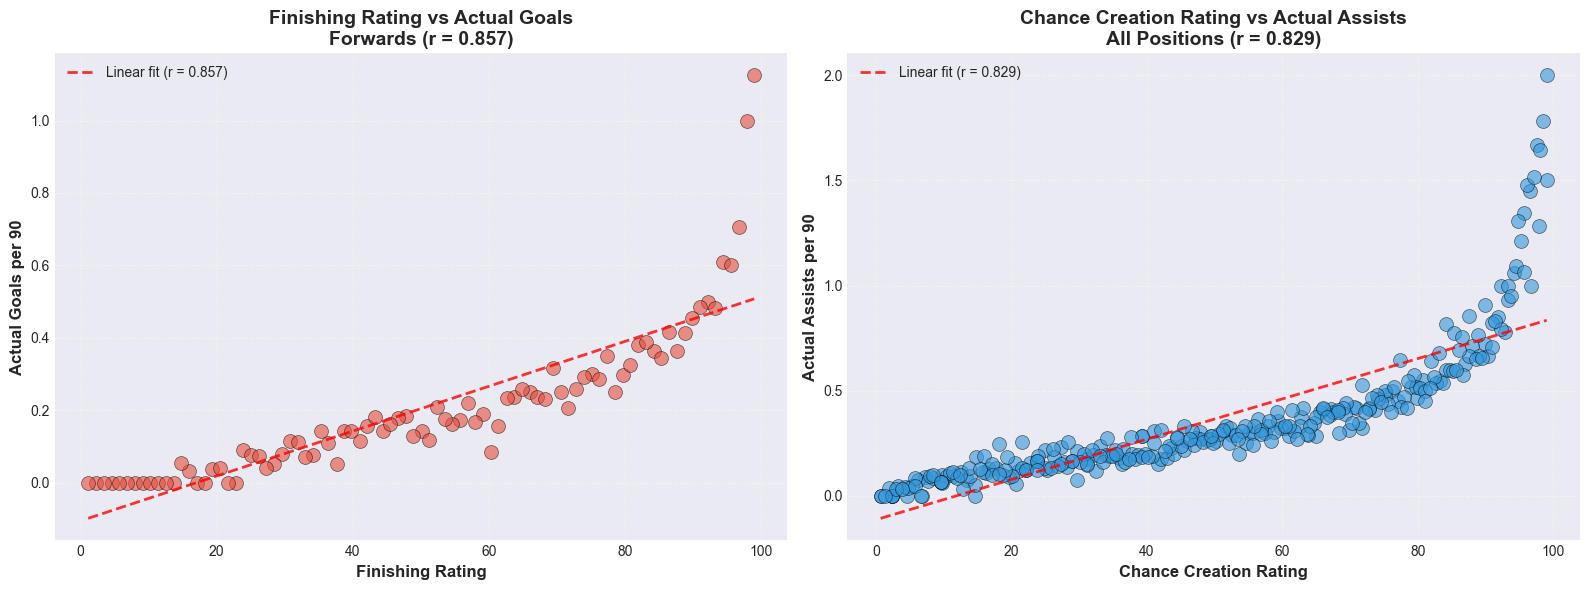

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/validation_correlations.png
Validation scatter plots created


In [6]:
# Cell 6: Create validation scatter plots

print("Creating validation scatter plots")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Finishing rating vs actual goals
ax1 = axes[0]
ax1.scatter(finishing_clean, goals_clean, alpha=0.6, s=100, color='#e74c3c', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Finishing Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual Goals per 90', fontsize=12, fontweight='bold')
ax1.set_title(f'Finishing Rating vs Actual Goals\nForwards (r = {corr_finishing:.3f})', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Add regression line
z = np.polyfit(finishing_clean, goals_clean, 1)
p = np.poly1d(z)
x_line = np.linspace(finishing_clean.min(), finishing_clean.max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, 
         label=f'Linear fit (r = {corr_finishing:.3f})')
ax1.legend(loc='upper left', fontsize=10)

# Plot 2: Chance creation rating vs actual assists
ax2 = axes[1]
ax2.scatter(creation_clean, assists_clean, alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Chance Creation Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual Assists per 90', fontsize=12, fontweight='bold')
ax2.set_title(f'Chance Creation Rating vs Actual Assists\nAll Positions (r = {corr_creation:.3f})', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

# Add regression line
z2 = np.polyfit(creation_clean, assists_clean, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(creation_clean.min(), creation_clean.max(), 100)
ax2.plot(x_line2, p2(x_line2), "r--", alpha=0.8, linewidth=2,
         label=f'Linear fit (r = {corr_creation:.3f})')
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'validation_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'validation_correlations.png'}")
print("Validation scatter plots created")

Creating top 20 players bar chart


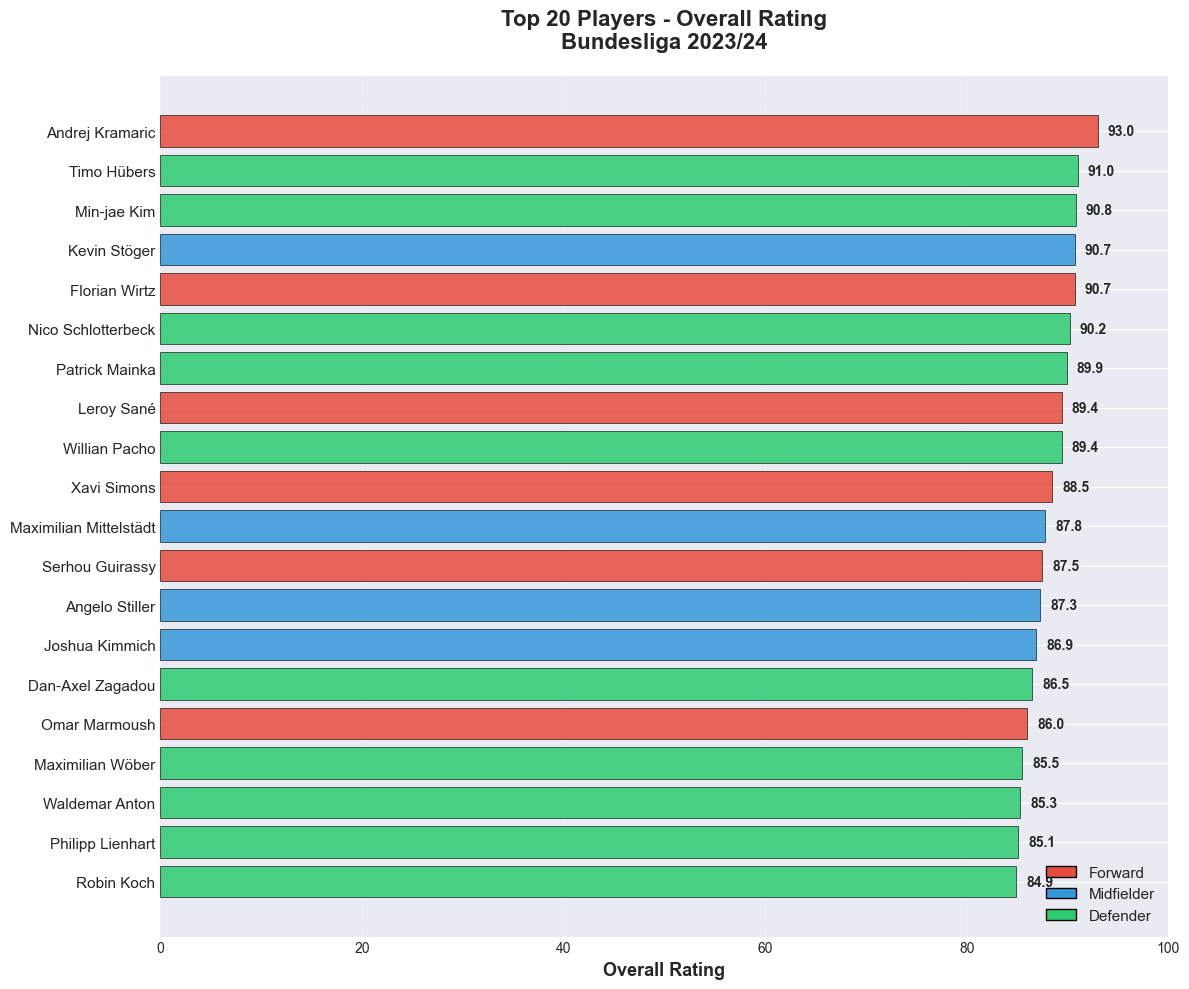

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/top20_overall_rating.png
Top 20 bar chart created


In [7]:
# Cell 7: Create top 20 players bar chart

print("Creating top 20 players bar chart")

# Get top 20 players by overall rating
top_20 = player_final.sort('overall_rating', descending=True).head(20)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Define position colors
position_colors = {
    'forward': '#e74c3c',
    'midfielder': '#3498db',
    'defender': '#2ecc71'
}
colors = [position_colors.get(pos, '#95a5a6') for pos in top_20['position'].to_list()]

# Create horizontal bar chart
y_pos = np.arange(len(top_20))
ratings = top_20['overall_rating'].to_list()
names = top_20['player_name'].to_list()

bars = ax.barh(y_pos, ratings, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

# Customize axes and labels
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Overall Rating', fontsize=13, fontweight='bold')
ax.set_title('Top 20 Players - Overall Rating\nBundesliga 2023/24', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add rating values on bars
for i, (bar, rating) in enumerate(zip(bars, ratings)):
    ax.text(rating + 1, i, f'{rating:.1f}', va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', label='Forward'),
    Patch(facecolor='#3498db', edgecolor='black', label='Midfielder'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Defender')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top20_overall_rating.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'top20_overall_rating.png'}")
print("Top 20 bar chart created")

Creating radar charts for top players by position

Creating radar charts for top player in each position:

1. Andrej Kramaric (Forward)


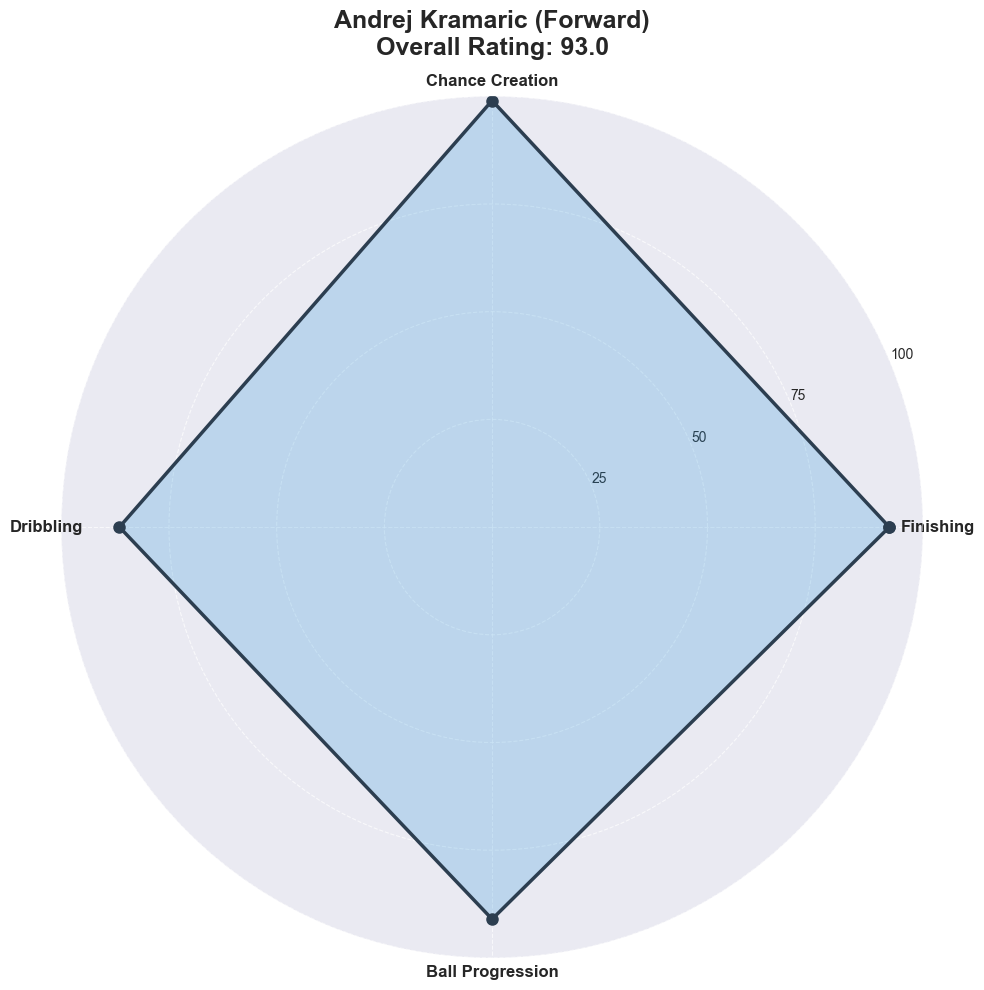

  Saved: radar_Andrej_Kramaric.png

2. Kevin Stöger (Midfielder)


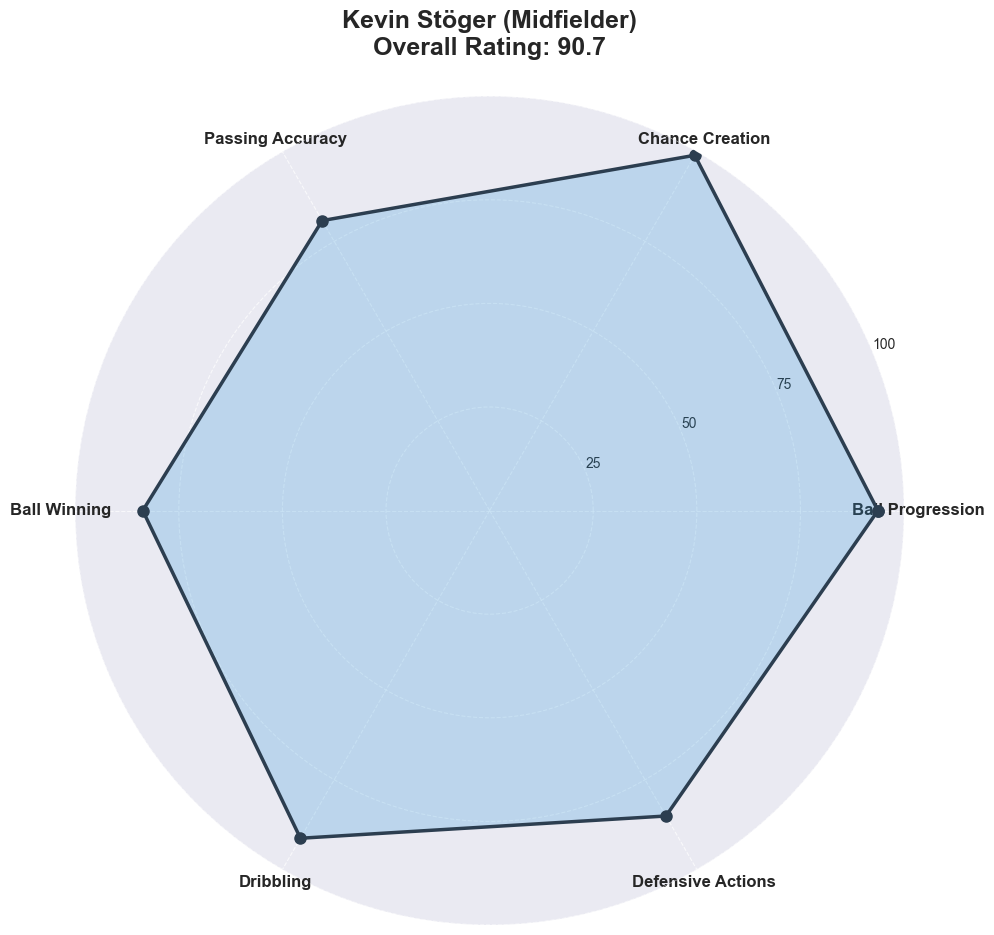

  Saved: radar_Kevin_Stöger.png

3. Timo Hübers (Defender)


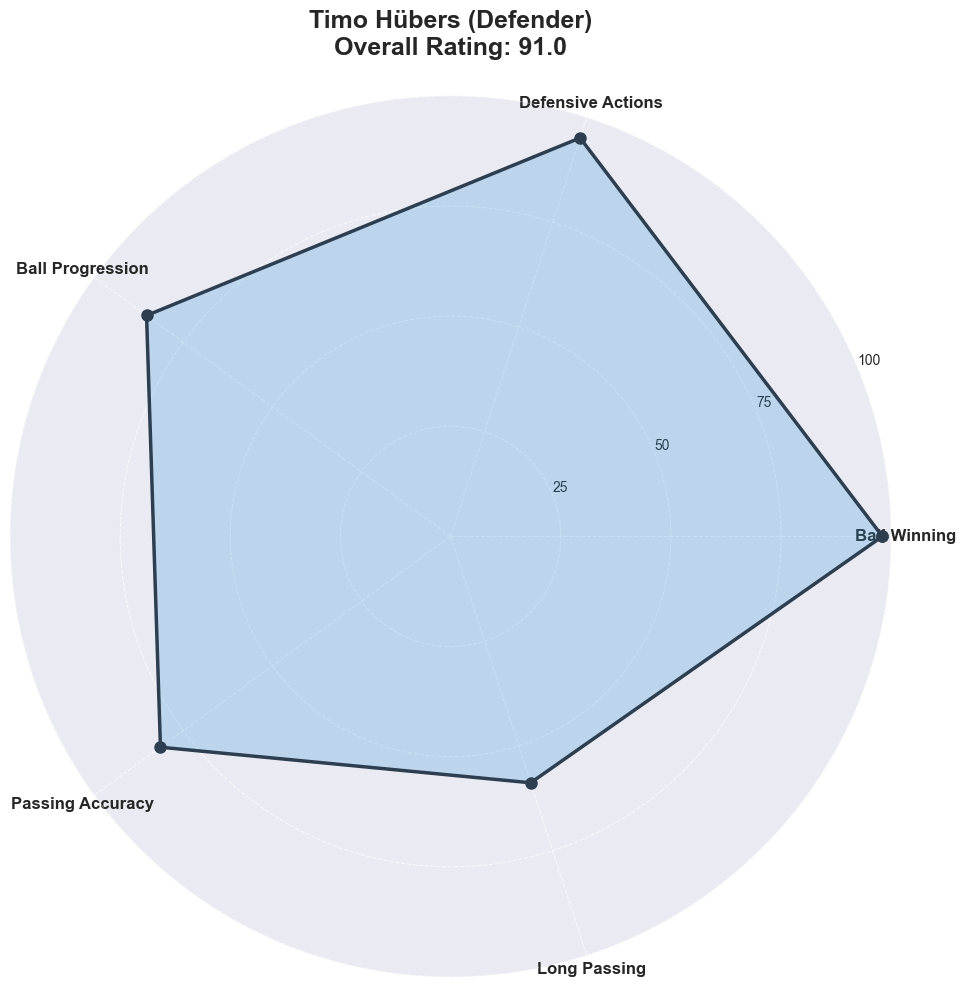

  Saved: radar_Timo_Hübers.png

Radar charts created for all positions


In [8]:
# Cell 8: Create radar charts for top players by position

print("Creating radar charts for top players by position")

def create_radar_chart(player_name, player_data, metrics, save_name):
    """
    Create radar chart showing player's performance across multiple metrics.
    
    Args:
        player_name: Player's name for title
        player_data: Single-row dataframe with player's ratings
        metrics: List of metric names to display
        save_name: Output filename
    """
    # Extract metric values
    values = []
    labels = []
    
    for metric in metrics:
        rating_col = f'{metric}_rating'
        if rating_col in player_data.columns:
            val = player_data[rating_col][0]
            if val is not None:
                values.append(val)
                labels.append(metric.replace('_', ' ').title())
    
    if len(values) == 0:
        print(f"No data available for {player_name}")
        return
    
    # Setup radar chart
    num_vars = len(values)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]  # Complete the circle
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot data
    ax.plot(angles, values, 'o-', linewidth=2.5, color='#2c3e50', markersize=8)
    ax.fill(angles, values, alpha=0.25, color='#3498db')
    
    # Customize axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add title with player info
    position = player_data['position'][0].title()
    overall = player_data['overall_rating'][0]
    
    plt.title(f'{player_name} ({position})\nOverall Rating: {overall:.1f}', 
              size=18, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved: {save_name}")


# Get top player from each position
print("\nCreating radar charts for top player in each position:")

top_forward = player_final.filter(pl.col('position') == 'forward').sort('overall_rating', descending=True).head(1)
top_midfielder = player_final.filter(pl.col('position') == 'midfielder').sort('overall_rating', descending=True).head(1)
top_defender = player_final.filter(pl.col('position') == 'defender').sort('overall_rating', descending=True).head(1)

# Define position-specific metrics to display
forward_metrics = ['finishing', 'chance_creation', 'dribbling', 'ball_progression']
midfielder_metrics = ['ball_progression', 'chance_creation', 'passing_accuracy', 
                      'ball_winning', 'dribbling', 'defensive_actions']
defender_metrics = ['ball_winning', 'defensive_actions', 'ball_progression', 
                    'passing_accuracy', 'long_passing']

# Create charts
if len(top_forward) > 0:
    player_name = top_forward['player_name'][0]
    print(f"\n1. {player_name} (Forward)")
    create_radar_chart(
        player_name,
        top_forward,
        forward_metrics,
        f"radar_{player_name.replace(' ', '_')}.png"
    )

if len(top_midfielder) > 0:
    player_name = top_midfielder['player_name'][0]
    print(f"\n2. {player_name} (Midfielder)")
    create_radar_chart(
        player_name,
        top_midfielder,
        midfielder_metrics,
        f"radar_{player_name.replace(' ', '_')}.png"
    )

if len(top_defender) > 0:
    player_name = top_defender['player_name'][0]
    print(f"\n3. {player_name} (Defender)")
    create_radar_chart(
        player_name,
        top_defender,
        defender_metrics,
        f"radar_{player_name.replace(' ', '_')}.png"
    )

print("\nRadar charts created for all positions")

In [9]:
# Cell 9: Create market value scatter plot (OPTIONAL - requires market value data)

print("Creating market value scatter plot")

# Check if market values exist
if 'market_value_millions' in player_final.columns:
    
    # Filter for players with market values
    with_values = player_final.filter(pl.col('market_value_millions').is_not_null())
    
    if len(with_values) > 0:
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Plot by position
        positions = ['forward', 'midfielder', 'defender']
        colors = {'forward': '#e74c3c', 'midfielder': '#3498db', 'defender': '#2ecc71'}
        markers = {'forward': 'o', 'midfielder': 's', 'defender': '^'}
        
        for position in positions:
            pos_data = with_values.filter(pl.col('position') == position)
            
            if len(pos_data) > 0:
                x = pos_data['market_value_millions'].to_list()
                y = pos_data['overall_rating'].to_list()
                
                ax.scatter(x, y, 
                          alpha=0.6, 
                          s=150, 
                          color=colors[position],
                          marker=markers[position],
                          edgecolors='black',
                          linewidth=0.5,
                          label=position.title())
        
        # Add fair value reference line (€15M = 50 rating)
        max_value = with_values['market_value_millions'].max()
        x_line = np.array([0, min(max_value, 130)])
        y_line = np.clip((x_line / 15.0) * 50, 0, 95)
        ax.plot(x_line, y_line, 'k--', alpha=0.5, linewidth=2, label='Fair Value Line')
        
        # Highlight hidden gems
        hidden_gems = with_values.filter(
            (pl.col('overall_rating') >= 85) &
            (pl.col('market_value_millions') < 15)
        )
        
        for row in hidden_gems.iter_rows(named=True):
            ax.annotate(
                row['player_name'],
                xy=(row['market_value_millions'], row['overall_rating']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
            )
        
        # Customize
        ax.set_xlabel('Market Value (€ Millions)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Overall Rating', fontsize=14, fontweight='bold')
        ax.set_title('Player Value Analysis: Rating vs Market Value\nBundesliga 2023/24', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_xlim(-5, max_value + 10)
        ax.set_ylim(0, 100)
        ax.legend(loc='lower right', fontsize=12, framealpha=0.95)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'market_value_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {FIGURES_DIR / 'market_value_scatter.png'}")
        print("Market value scatter plot created")
    else:
        print("No players with market values found")
else:
    print("Market value column not found - skipping this visualization")
    print("This is optional - core validation uses goals/assists correlation")

Creating market value scatter plot
Market value column not found - skipping this visualization
This is optional - core validation uses goals/assists correlation


Creating top performers by position visualization


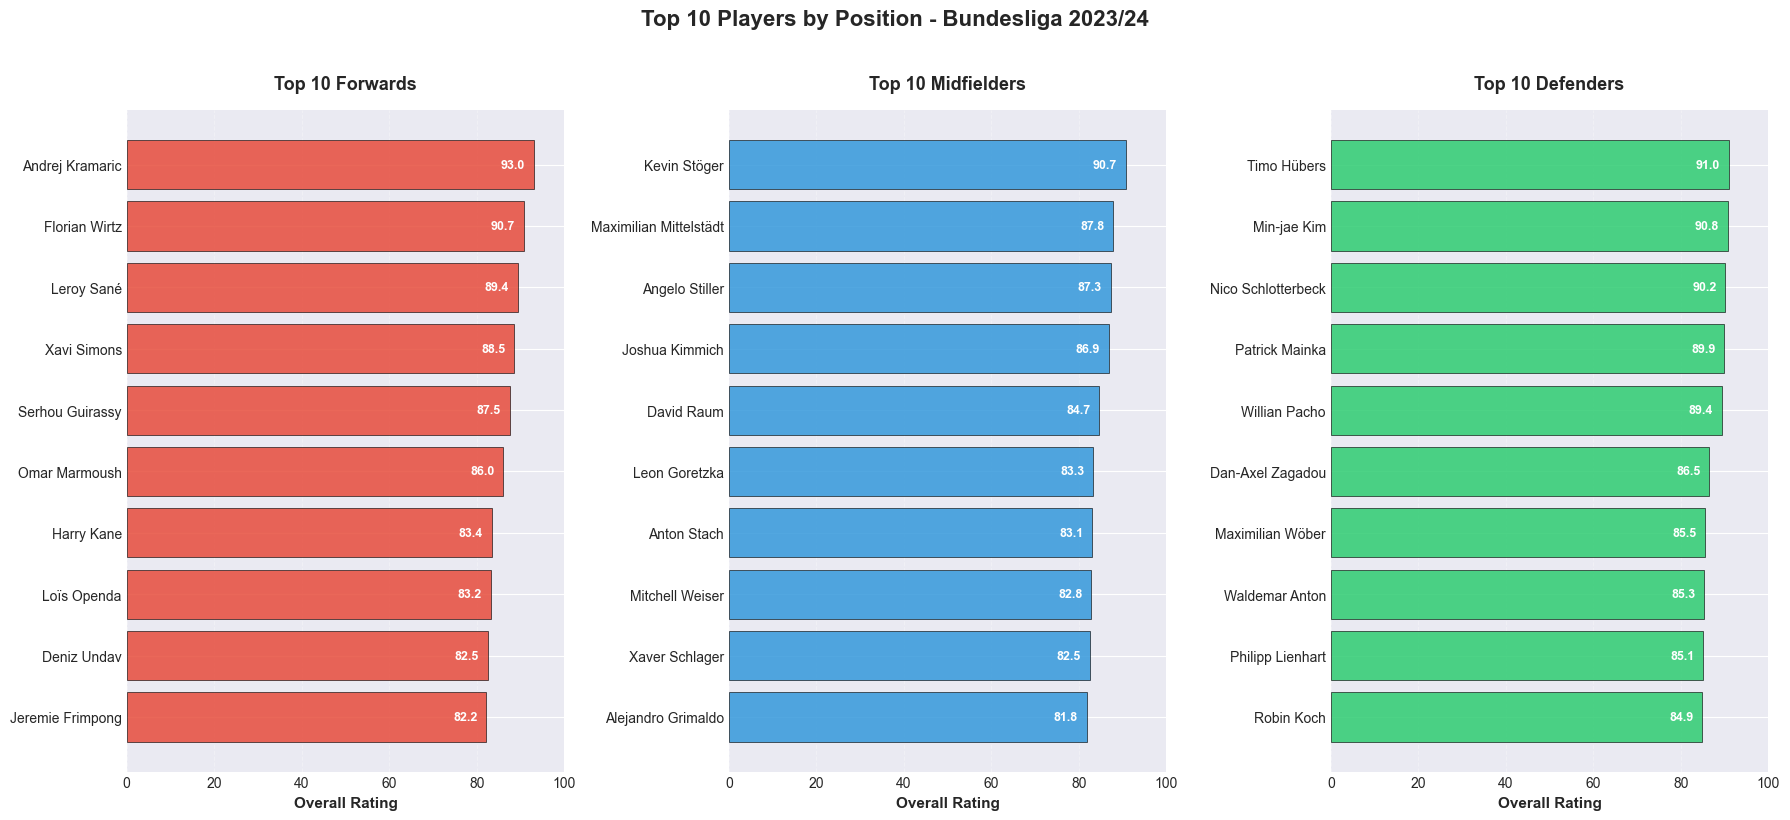

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/top10_by_position.png
Position-based top performers visualization created


In [10]:
# Cell: Create top performers by position visualization

print("Creating top performers by position visualization")

# Create figure with 3 subplots (one per position)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

positions = ['forward', 'midfielder', 'defender']
colors = {'forward': '#e74c3c', 'midfielder': '#3498db', 'defender': '#2ecc71'}
titles = {'forward': 'Top 10 Forwards', 'midfielder': 'Top 10 Midfielders', 'defender': 'Top 10 Defenders'}

for idx, (position, ax) in enumerate(zip(positions, axes)):
    # Get top 10 in this position
    top_10 = player_final.filter(pl.col('position') == position).sort('overall_rating', descending=True).head(10)
    
    if len(top_10) == 0:
        continue
    
    # Prepare data
    names = top_10['player_name'].to_list()
    ratings = top_10['overall_rating'].to_list()
    
    y_pos = np.arange(len(names))
    
    # Create horizontal bars
    bars = ax.barh(y_pos, ratings, color=colors[position], alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # Customize axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Overall Rating', fontsize=11, fontweight='bold')
    ax.set_title(titles[position], fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(0, 100)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add rating values on bars
    for i, (bar, rating) in enumerate(zip(bars, ratings)):
        ax.text(rating - 2, i, f'{rating:.1f}', 
                va='center', ha='right', fontsize=9, fontweight='bold', color='white')

plt.suptitle('Top 10 Players by Position - Bundesliga 2023/24', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top10_by_position.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'top10_by_position.png'}")
print("Position-based top performers visualization created")

Creating position comparison scatter plots


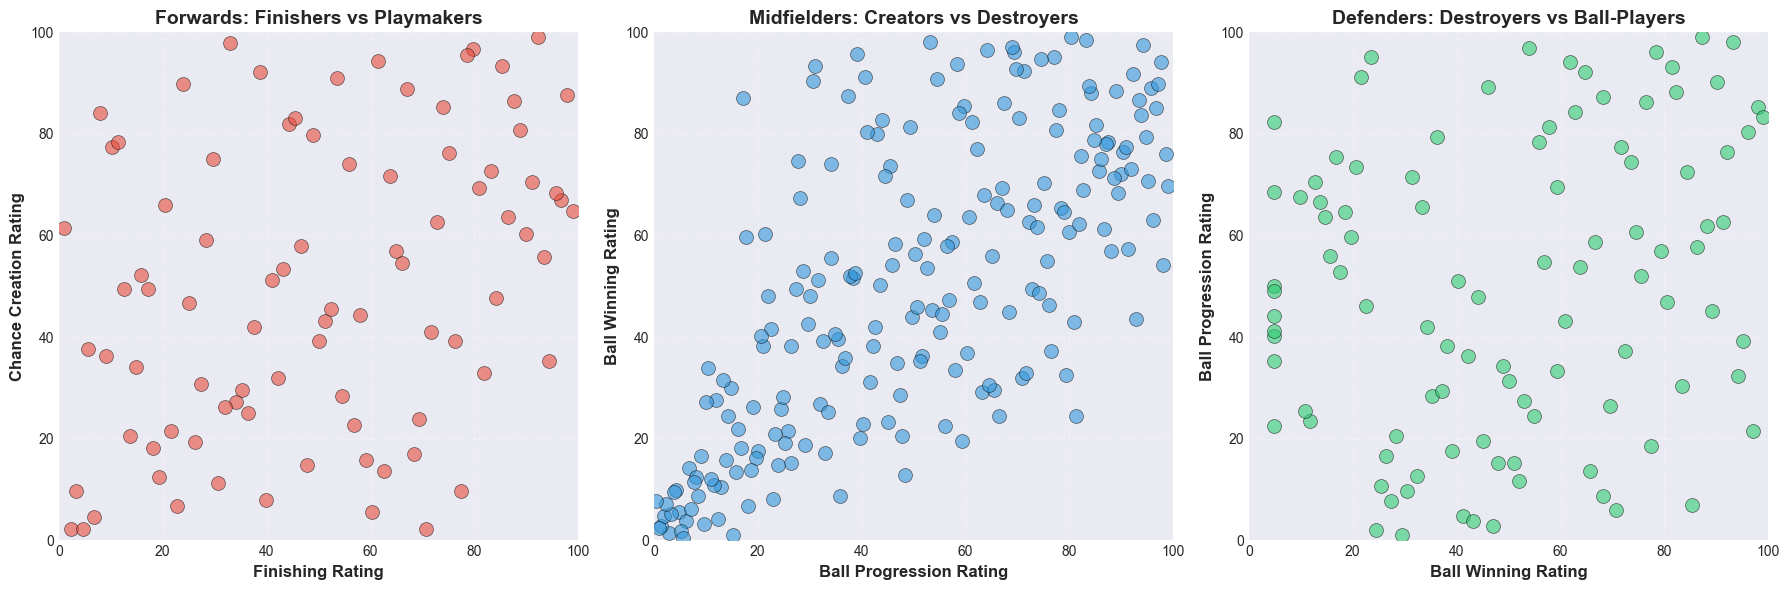

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/position_comparison_scatter.png
Position comparison visualization created


In [11]:
# Cell 10: Create position comparison scatter plots

print("Creating position comparison scatter plots")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Forward: Finishing vs Chance Creation
forwards_viz = player_final.filter(pl.col('position') == 'forward')
ax1 = axes[0]
ax1.scatter(forwards_viz['finishing_rating'], forwards_viz['chance_creation_rating'],
            alpha=0.6, s=100, color='#e74c3c', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Finishing Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Chance Creation Rating', fontsize=12, fontweight='bold')
ax1.set_title('Forwards: Finishers vs Playmakers', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# Midfielder: Ball Progression vs Ball Winning
mids_viz = player_final.filter(pl.col('position') == 'midfielder')
ax2 = axes[1]
ax2.scatter(mids_viz['ball_progression_rating'], mids_viz['ball_winning_rating'],
            alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Ball Progression Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ball Winning Rating', fontsize=12, fontweight='bold')
ax2.set_title('Midfielders: Creators vs Destroyers', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)

# Defender: Ball Winning vs Ball Progression
defs_viz = player_final.filter(pl.col('position') == 'defender')
ax3 = axes[2]
ax3.scatter(defs_viz['ball_winning_rating'], defs_viz['ball_progression_rating'],
            alpha=0.6, s=100, color='#2ecc71', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Ball Winning Rating', fontsize=12, fontweight='bold')
ax3.set_ylabel('Ball Progression Rating', fontsize=12, fontweight='bold')
ax3.set_title('Defenders: Destroyers vs Ball-Players', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(0, 100)
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'position_comparison_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'position_comparison_scatter.png'}")
print("Position comparison visualization created")

Creating metric distribution histogram


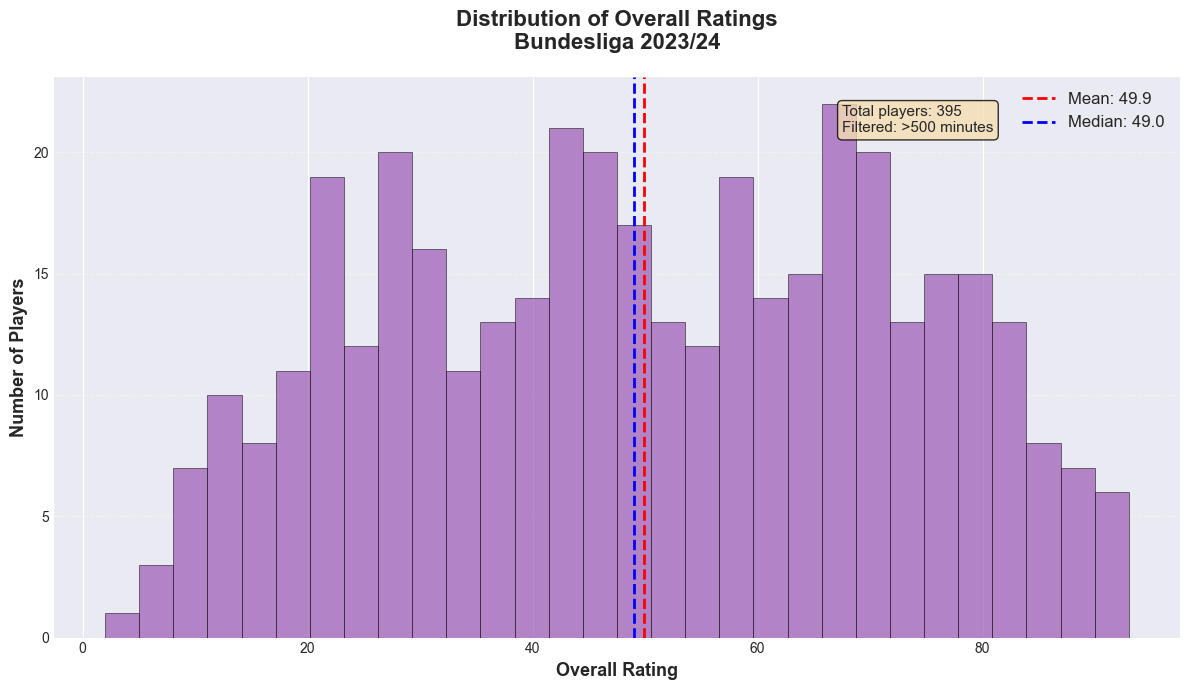

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/rating_distribution.png
Rating distribution histogram created


In [12]:
# Cell: Create metric distribution histogram

print("Creating metric distribution histogram")

# Select a key metric to visualize distribution
metric_to_plot = 'overall_rating'

fig, ax = plt.subplots(figsize=(12, 7))

# Create histogram
ratings = player_final[metric_to_plot].to_numpy()
ax.hist(ratings, bins=30, alpha=0.7, color='#9b59b6', edgecolor='black', linewidth=0.5)

# Add statistical markers
mean_rating = ratings.mean()
median_rating = np.median(ratings)

ax.axvline(mean_rating, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rating:.1f}')
ax.axvline(median_rating, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_rating:.1f}')

# Customize
ax.set_xlabel('Overall Rating', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Overall Ratings\nBundesliga 2023/24', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add annotation
ax.text(0.7, 0.95, f'Total players: {len(player_final)}\nFiltered: >500 minutes',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'rating_distribution.png'}")
print("Rating distribution histogram created")

Testing mplsoccer pitch visualization


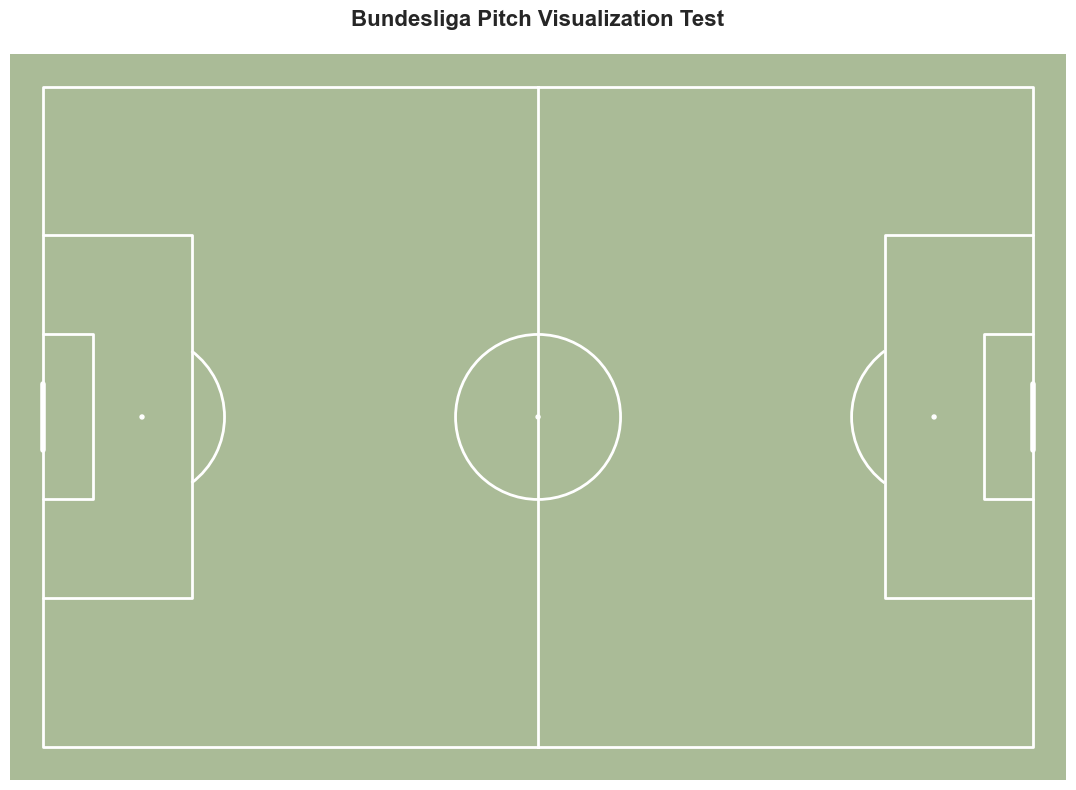

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/test_pitch.png

Coordinate system notes:
  Our data (secondspectrum): X=[-52.5, 52.5], Y=[-34.0, 34.0]
  mplsoccer (statsbomb): X=[0, 120], Y=[0, 80]
  Transformation needed: x_new = x_old + 52.5, y_new = y_old + 34

mplsoccer test complete


In [13]:
# Cell: Test mplsoccer pitch visualization

print("Testing mplsoccer pitch visualization")

from mplsoccer import Pitch

# Create simple pitch to verify mplsoccer works
pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white',
              linewidth=2, line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

ax.set_title('Bundesliga Pitch Visualization Test', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_pitch.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'test_pitch.png'}")

# Note about coordinate transformation
print("\nCoordinate system notes:")
print("  Our data (secondspectrum): X=[-52.5, 52.5], Y=[-34.0, 34.0]")
print("  mplsoccer (statsbomb): X=[0, 120], Y=[0, 80]")
print("  Transformation needed: x_new = x_old + 52.5, y_new = y_old + 34")

print("\nmplsoccer test complete")

Creating progressive pass map
Top ball progressor: Florian Wirtz (Rating: 99.0)
Progressive passes found: 196


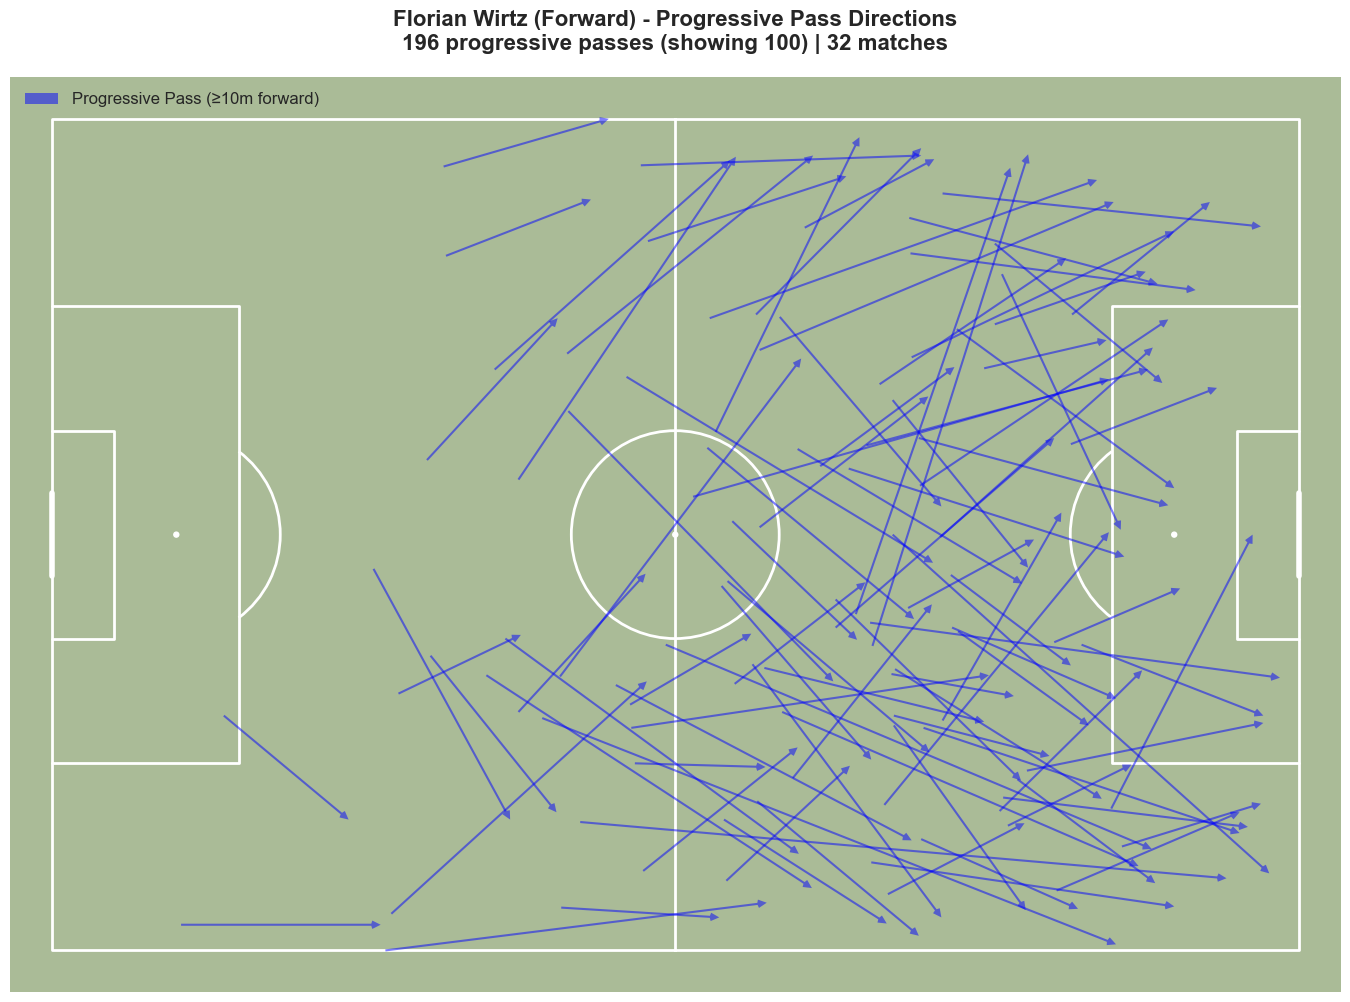

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/progressive_passes_Florian_Wirtz.png
Progressive pass map created


In [14]:
# Cell: Create progressive pass map for top ball progressor

print("Creating progressive pass map")

# Get top ball progression player
top_progressor = player_final.filter(
    pl.col('ball_progression_rating').is_not_null()
).sort('ball_progression_rating', descending=True).head(1)

if len(top_progressor) == 0:
    print("No data available")
else:
    player_name = top_progressor['player_name'][0]
    player_id = top_progressor['player_id'][0]
    prog_rating = top_progressor['ball_progression_rating'][0]
    
    print(f"Top ball progressor: {player_name} (Rating: {prog_rating:.1f})")
    
    # Get player's complete passes
    player_passes = all_events.filter(
        (pl.col('player_id') == player_id) &
        (pl.col('event_type') == 'PASS') &
        (pl.col('result') == 'COMPLETE') &
        (pl.col('coordinates_x').is_not_null()) &
        (pl.col('end_coordinates_x').is_not_null())
    )
    
    # Filter for progressive passes (≥10m forward)
    progressive_passes = []
    for row in player_passes.iter_rows(named=True):
        forward_dist = row['end_coordinates_x'] - row['coordinates_x']
        if forward_dist >= 10:
            progressive_passes.append(row)
    
    print(f"Progressive passes found: {len(progressive_passes)}")
    
    if len(progressive_passes) > 0:
        from mplsoccer import Pitch
        
        # Create pitch
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', 
                      line_color='white', linewidth=2)
        fig, ax = pitch.draw(figsize=(14, 10))
        
        # Sample to avoid clutter (max 100 passes)
        sample_size = min(100, len(progressive_passes))
        
        for p in progressive_passes[:sample_size]:
            # Transform coordinates: secondspectrum to statsbomb
            # Secondspectrum: x∈[-52.5,52.5], y∈[-34,34]
            # StatsBomb: x∈[0,120], y∈[0,80]
            start_x = (p['coordinates_x'] + 52.5) * (120 / 105)
            start_y = (p['coordinates_y'] + 34) * (80 / 68)
            end_x = (p['end_coordinates_x'] + 52.5) * (120 / 105)
            end_y = (p['end_coordinates_y'] + 34) * (80 / 68)
            
            # Plot arrow
            pitch.arrows(start_x, start_y, end_x, end_y,
                         width=1.5, headwidth=4, headlength=4,
                         color='blue', alpha=0.5, ax=ax)
        
        # Title
        position = top_progressor['position'][0]
        matches = top_progressor['matches_played'][0]
        
        ax.set_title(f'{player_name} ({position.title()}) - Progressive Pass Directions\n'
                     f'{len(progressive_passes)} progressive passes (showing {sample_size}) | {matches} matches',
                     fontsize=16, fontweight='bold', pad=20)
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='blue', alpha=0.5, label='Progressive Pass (≥10m forward)')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
        
        plt.tight_layout()
        
        # Save
        filename = f'progressive_passes_{player_name.replace(" ", "_")}.png'
        filepath = FIGURES_DIR / filename
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {filepath}")
        print("Progressive pass map created")
    else:
        print("No progressive passes to visualize")

Creating shot map for top finisher
Top finisher: Harry Kane (Rating: 99.0)
Total shots: 141


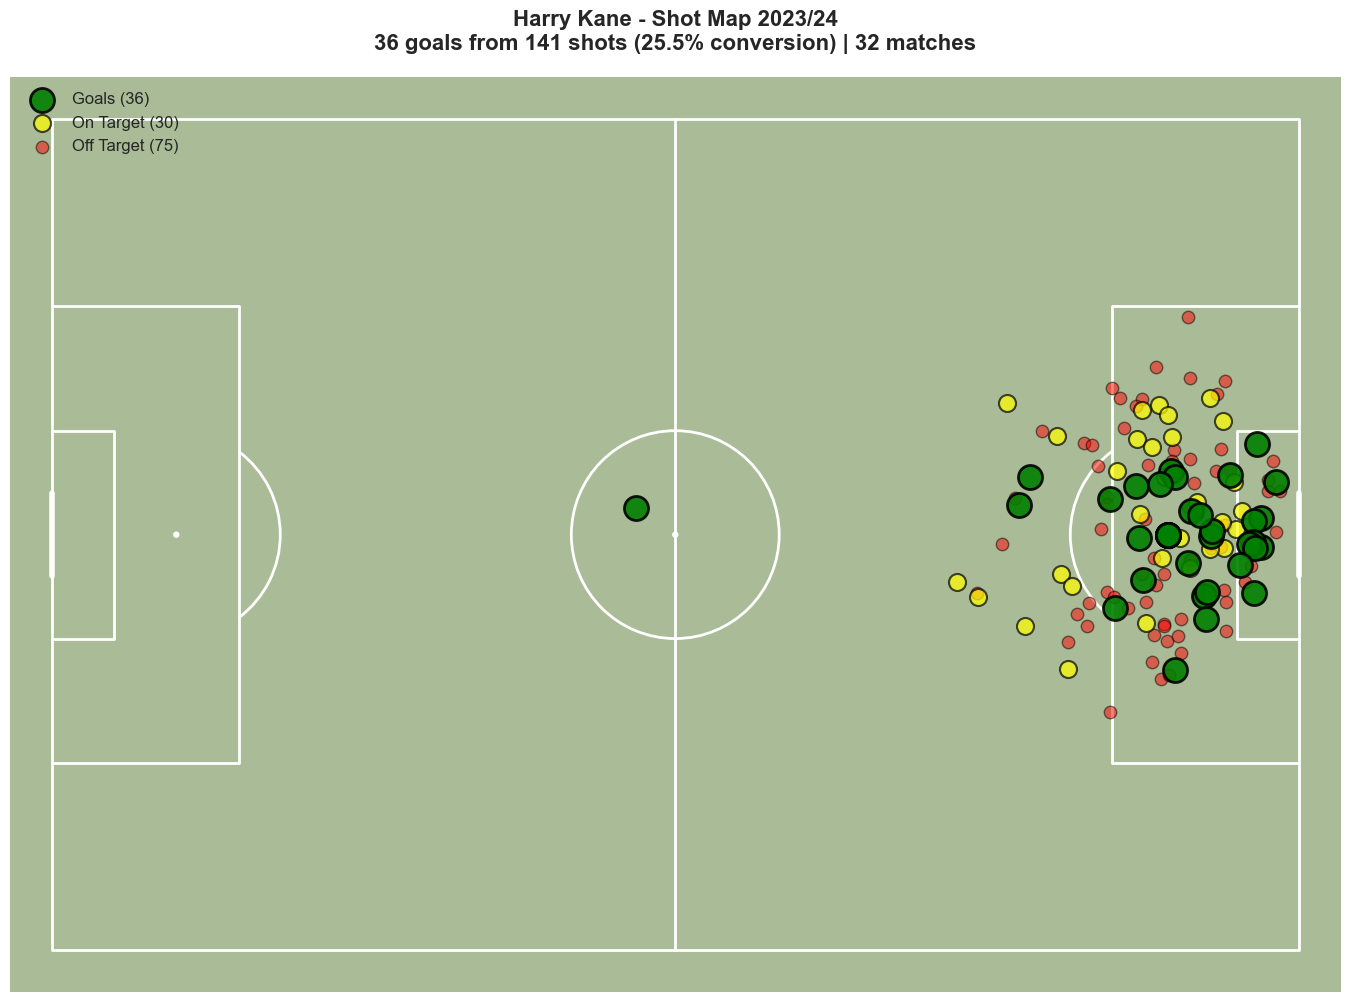

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/shot_map_Harry_Kane.png
Shot map created


In [15]:
# Cell: Create shot map for top finisher

print("Creating shot map for top finisher")

# Get top finishing player
top_finisher = player_final.filter(
    (pl.col('position') == 'forward') &
    (pl.col('finishing_rating').is_not_null())
).sort('finishing_rating', descending=True).head(1)

if len(top_finisher) == 0:
    print("No data available")
else:
    player_name = top_finisher['player_name'][0]
    player_id = top_finisher['player_id'][0]
    finishing_rating = top_finisher['finishing_rating'][0]
    
    print(f"Top finisher: {player_name} (Rating: {finishing_rating:.1f})")
    
    # Get all shots by this player
    player_shots = all_events.filter(
        (pl.col('player_id') == player_id) &
        (pl.col('event_type') == 'SHOT') &
        (pl.col('coordinates_x').is_not_null())
    )
    
    print(f"Total shots: {len(player_shots)}")
    
    if len(player_shots) > 0:
        # Categorize by outcome
        goals = []
        on_target = []
        off_target = []
        
        for row in player_shots.iter_rows(named=True):
            shot_data = {
                'x': row['coordinates_x'],
                'y': row['coordinates_y'],
                'result': row['result']
            }
            
            if row['result'] == 'GOAL':
                goals.append(shot_data)
            elif row['result'] == 'SAVED':
                on_target.append(shot_data)
            else:
                off_target.append(shot_data)
        
        from mplsoccer import Pitch
        
        # Create pitch
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                      line_color='white', linewidth=2)
        fig, ax = pitch.draw(figsize=(14, 10))
        
        # Transform coordinates: secondspectrum to statsbomb
        # Secondspectrum: x∈[-52.5,52.5], y∈[-34,34]
        # StatsBomb: x∈[0,120], y∈[0,80]
        
        # Plot goals (green, large)
        if len(goals) > 0:
            goal_x = [(g['x'] + 52.5) * (120/105) for g in goals]
            goal_y = [(g['y'] + 34) * (80/68) for g in goals]
            pitch.scatter(goal_x, goal_y, s=300, color='green', 
                         edgecolors='black', linewidth=2, zorder=3,
                         label=f'Goals ({len(goals)})', ax=ax, alpha=0.9)
        
        # Plot on-target shots (yellow, medium)
        if len(on_target) > 0:
            on_x = [(s['x'] + 52.5) * (120/105) for s in on_target]
            on_y = [(s['y'] + 34) * (80/68) for s in on_target]
            pitch.scatter(on_x, on_y, s=150, color='yellow',
                         edgecolors='black', linewidth=1.5, zorder=2,
                         label=f'On Target ({len(on_target)})', ax=ax, alpha=0.7)
        
        # Plot off-target shots (red, small)
        if len(off_target) > 0:
            off_x = [(s['x'] + 52.5) * (120/105) for s in off_target]
            off_y = [(s['y'] + 34) * (80/68) for s in off_target]
            pitch.scatter(off_x, off_y, s=80, color='red',
                         edgecolors='black', linewidth=1, zorder=1,
                         label=f'Off Target ({len(off_target)})', ax=ax, alpha=0.5)
        
        # Title with statistics
        matches = top_finisher['matches_played'][0]
        total_shots = len(player_shots)
        conversion = len(goals) / total_shots * 100 if total_shots > 0 else 0
        
        ax.set_title(f'{player_name} - Shot Map 2023/24\n'
                     f'{len(goals)} goals from {total_shots} shots ({conversion:.1f}% conversion) | {matches} matches',
                     fontsize=16, fontweight='bold', pad=20)
        
        ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
        
        plt.tight_layout()
        
        # Save
        filename = f'shot_map_{player_name.replace(" ", "_")}.png'
        filepath = FIGURES_DIR / filename
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {filepath}")
        print("Shot map created")
    else:
        print("No shots to visualize")

Creating key passes map for top playmaker
Top playmaker: Andrej Kramaric (Rating: 99.0)
Key passes found: 138


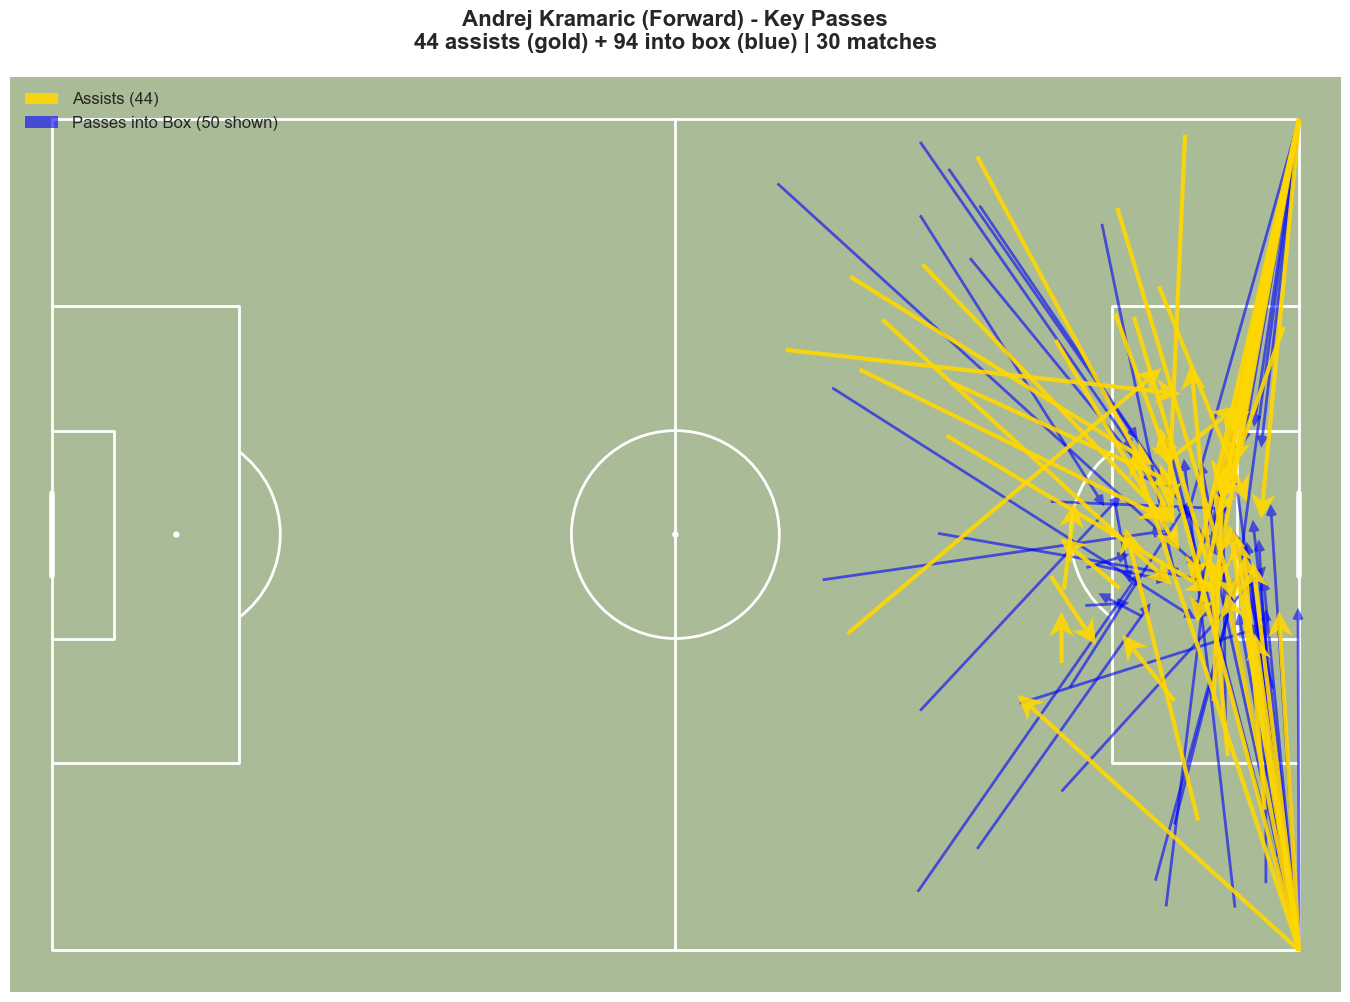

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/key_passes_Andrej_Kramaric.png
Key passes map created


In [16]:
# Cell: Create key passes map for top playmaker

print("Creating key passes map for top playmaker")

# Get top chance creation player
top_playmaker = player_final.filter(
    pl.col('chance_creation_rating').is_not_null()
).sort('chance_creation_rating', descending=True).head(1)

if len(top_playmaker) == 0:
    print("No data available")
else:
    player_name = top_playmaker['player_name'][0]
    player_id = top_playmaker['player_id'][0]
    creation_rating = top_playmaker['chance_creation_rating'][0]
    
    print(f"Top playmaker: {player_name} (Rating: {creation_rating:.1f})")
    
    # Get key passes (assists and passes into box)
    player_key_passes = all_events.filter(
        (pl.col('player_id') == player_id) &
        (pl.col('event_type') == 'PASS') &
        (pl.col('coordinates_x').is_not_null()) &
        (pl.col('end_coordinates_x').is_not_null()) &
        (pl.col('coordinates_y').is_not_null()) &
        (pl.col('end_coordinates_y').is_not_null()) &
        (
            (pl.col('pass_type') == 'SHOT_ASSIST') |
            (
                (pl.col('end_coordinates_x') > 35.5) &
                (pl.col('end_coordinates_y').abs() < 9.15)
            )
        )
    )
    
    print(f"Key passes found: {len(player_key_passes)}")
    
    if len(player_key_passes) > 0:
        from mplsoccer import Pitch
        
        # Create pitch
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                      line_color='white', linewidth=2)
        fig, ax = pitch.draw(figsize=(14, 10))
        
        # Separate assists from other key passes
        assists = []
        other_key = []
        
        for row in player_key_passes.iter_rows(named=True):
            # Transform coordinates
            x_start = (row['coordinates_x'] + 52.5) * (120/105)
            y_start = (row['coordinates_y'] + 34) * (80/68)
            x_end = (row['end_coordinates_x'] + 52.5) * (120/105)
            y_end = (row['end_coordinates_y'] + 34) * (80/68)
            
            if row.get('pass_type') == 'SHOT_ASSIST':
                assists.append((x_start, y_start, x_end, y_end))
            else:
                other_key.append((x_start, y_start, x_end, y_end))
        
        # Plot assists (gold, thick)
        if len(assists) > 0:
            for x1, y1, x2, y2 in assists:
                pitch.arrows(x1, y1, x2, y2,
                             width=3, headwidth=6, headlength=6,
                             color='gold', alpha=0.9, ax=ax, zorder=3)
        
        # Plot passes into box (blue, sample max 50)
        if len(other_key) > 0:
            for x1, y1, x2, y2 in other_key[:50]:
                pitch.arrows(x1, y1, x2, y2,
                             width=2, headwidth=4, headlength=4,
                             color='blue', alpha=0.6, ax=ax, zorder=2)
        
        # Title with statistics
        position = top_playmaker['position'][0]
        matches = top_playmaker['matches_played'][0]
        total_assists = len(assists)
        
        ax.set_title(f'{player_name} ({position.title()}) - Key Passes\n'
                     f'{total_assists} assists (gold) + {len(other_key)} into box (blue) | {matches} matches',
                     fontsize=16, fontweight='bold', pad=20)
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='gold', alpha=0.9, label=f'Assists ({total_assists})'),
            Patch(facecolor='blue', alpha=0.6, label=f'Passes into Box ({min(50, len(other_key))} shown)')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
        
        plt.tight_layout()
        
        # Save
        filename = f'key_passes_{player_name.replace(" ", "_")}.png'
        filepath = FIGURES_DIR / filename
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {filepath}")
        print("Key passes map created")
    else:
        print("No key passes to visualize")

Creating positional heatmap for top playmaker
Top playmaker: Andrej Kramaric (Rating: 99.0)
Events with coordinates: 3278


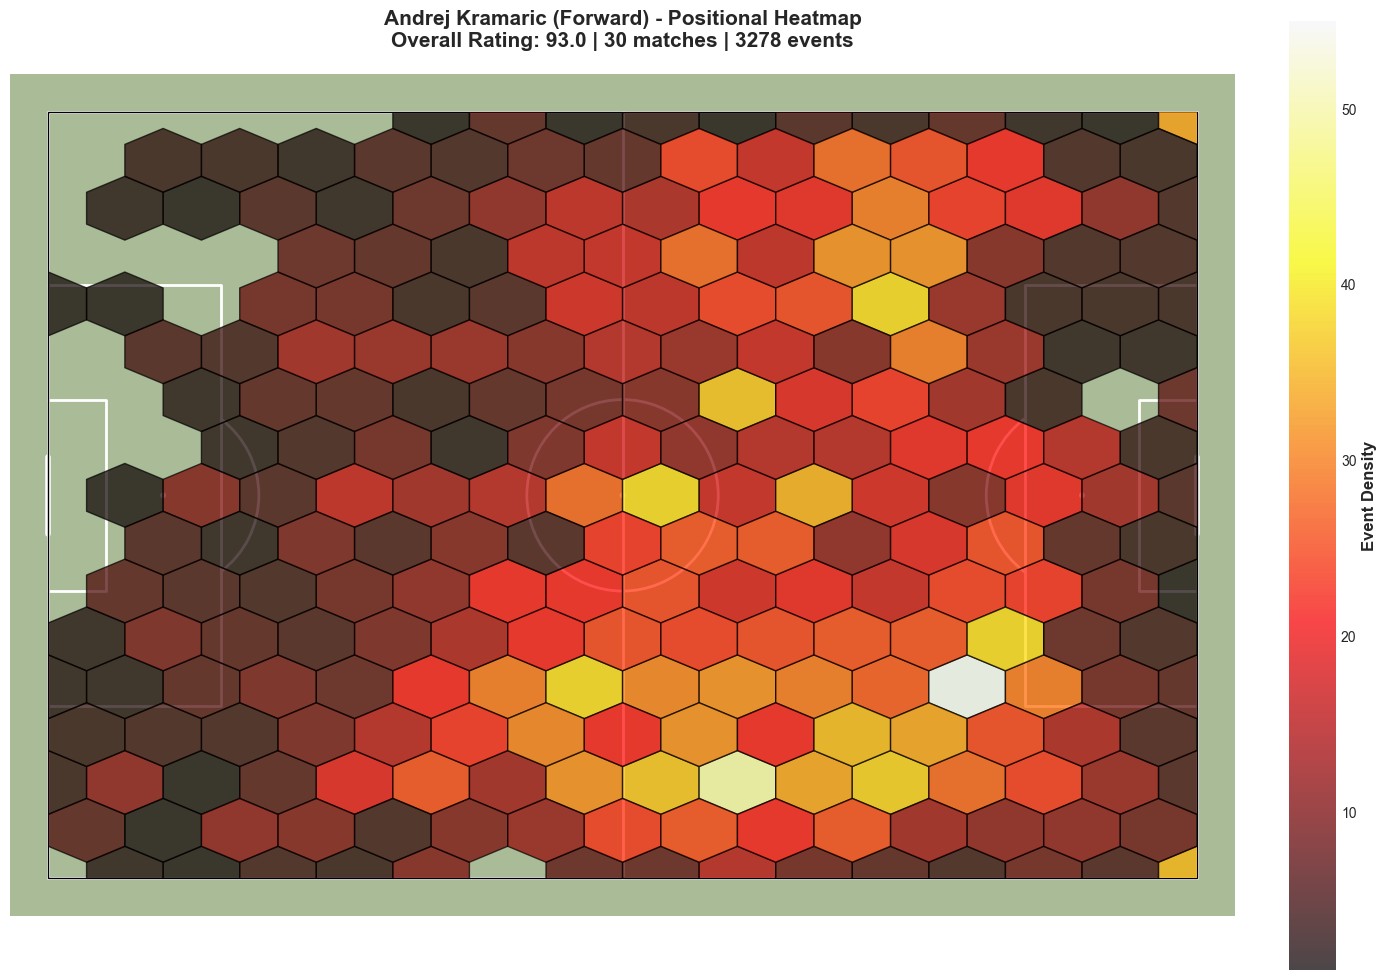

Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/heatmap_Andrej_Kramaric.png
Positional heatmap created


In [17]:
# Cell: Create positional heatmap for top playmaker

print("Creating positional heatmap for top playmaker")

# Get top chance creation player
top_playmaker = player_final.filter(
    pl.col('chance_creation_rating').is_not_null()
).sort('chance_creation_rating', descending=True).head(1)

if len(top_playmaker) == 0:
    print("No data available")
else:
    player_name = top_playmaker['player_name'][0]
    player_id = top_playmaker['player_id'][0]
    creation_rating = top_playmaker['chance_creation_rating'][0]
    
    print(f"Top playmaker: {player_name} (Rating: {creation_rating:.1f})")
    
    # Get all events with coordinates for this player
    player_events = all_events.filter(
        (pl.col('player_id') == player_id) &
        (pl.col('coordinates_x').is_not_null()) &
        (pl.col('coordinates_y').is_not_null())
    )
    
    print(f"Events with coordinates: {len(player_events)}")
    
    if len(player_events) > 0:
        from mplsoccer import Pitch
        
        # Transform coordinates to statsbomb
        x_coords = [(x + 52.5) * (120/105) for x in player_events['coordinates_x'].to_list()]
        y_coords = [(y + 34) * (80/68) for y in player_events['coordinates_y'].to_list()]
        
        # Create pitch
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                      line_color='white', linewidth=2)
        fig, ax = pitch.draw(figsize=(14, 10))
        
        # Create hexbin heatmap
        hexmap = pitch.hexbin(x_coords, y_coords, ax=ax, 
                             edgecolors='black', gridsize=15,
                             cmap='hot', alpha=0.7, zorder=2)
        
        # Add colorbar
        cbar = plt.colorbar(hexmap, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Event Density', fontsize=12, fontweight='bold')
        
        # Title
        position = top_playmaker['position'][0]
        overall = top_playmaker['overall_rating'][0]
        matches = top_playmaker['matches_played'][0]
        
        ax.set_title(f'{player_name} ({position.title()}) - Positional Heatmap\n'
                     f'Overall Rating: {overall:.1f} | {matches} matches | {len(player_events)} events',
                     fontsize=15, fontweight='bold', pad=20)
        
        plt.tight_layout()
        
        # Save
        filename = f'heatmap_{player_name.replace(" ", "_")}.png'
        filepath = FIGURES_DIR / filename
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {filepath}")
        print("Positional heatmap created")
    else:
        print("No events with coordinates to visualize")

In [18]:
# Cell: Create position-appropriate pitch visualizations

print("Creating position-appropriate pitch visualizations")

from mplsoccer import Pitch

def create_player_pitch_viz(player_data, all_events_df, save_name):
    """
    Create position-appropriate pitch visualization.
    Forwards: Shot map showing goals, on-target, off-target
    Midfielders/Defenders: Progressive pass map
    """
    player_name = player_data['player_name'][0]
    player_id = player_data['player_id'][0]
    position = player_data['position'][0]
    overall = player_data['overall_rating'][0]
    matches = player_data['matches_played'][0]
    
    print(f"  Creating visualization for {player_name} ({position})")
    
    # Create pitch
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                  line_color='white', linewidth=1.5)
    fig, ax = pitch.draw(figsize=(10, 7))
    
    # For forwards: shot map
    if position == 'forward':
        shots = all_events_df.filter(
            (pl.col('player_id') == player_id) &
            (pl.col('event_type') == 'SHOT') &
            (pl.col('coordinates_x').is_not_null()) &
            (pl.col('coordinates_y').is_not_null())
        )
        
        goals, saved, missed = [], [], []
        
        for row in shots.iter_rows(named=True):
            x = (row['coordinates_x'] + 52.5) * (120/105)
            y = (row['coordinates_y'] + 34) * (80/68)
            
            if row['result'] == 'GOAL':
                goals.append((x, y))
            elif row['result'] == 'SAVED':
                saved.append((x, y))
            else:
                missed.append((x, y))
        
        # Plot shots by outcome
        if goals:
            pitch.scatter([g[0] for g in goals], [g[1] for g in goals],
                         s=200, color='green', edgecolors='black', linewidth=2,
                         label=f'Goals ({len(goals)})', ax=ax, zorder=3, alpha=0.9)
        
        if saved:
            pitch.scatter([s[0] for s in saved], [s[1] for s in saved],
                         s=120, color='yellow', edgecolors='black', linewidth=1.5,
                         label=f'On Target ({len(saved)})', ax=ax, zorder=2, alpha=0.7)
        
        if missed:
            pitch.scatter([m[0] for m in missed], [m[1] for m in missed],
                         s=60, color='red', edgecolors='black', linewidth=1,
                         label=f'Off Target ({len(missed)})', ax=ax, zorder=1, alpha=0.5)
        
        total_events = len(shots)
        viz_type = 'Shot Map'
    
    # For midfielders/defenders: progressive pass map
    else:
        passes = all_events_df.filter(
            (pl.col('player_id') == player_id) &
            (pl.col('event_type') == 'PASS') &
            (pl.col('result') == 'COMPLETE') &
            (pl.col('coordinates_x').is_not_null()) &
            (pl.col('end_coordinates_x').is_not_null()) &
            (pl.col('coordinates_y').is_not_null()) &
            (pl.col('end_coordinates_y').is_not_null())
        )
        
        progressive = []
        for row in passes.iter_rows(named=True):
            forward_dist = row['end_coordinates_x'] - row['coordinates_x']
            if forward_dist >= 10:
                x1 = (row['coordinates_x'] + 52.5) * (120/105)
                y1 = (row['coordinates_y'] + 34) * (80/68)
                x2 = (row['end_coordinates_x'] + 52.5) * (120/105)
                y2 = (row['end_coordinates_y'] + 34) * (80/68)
                progressive.append((x1, y1, x2, y2))
        
        # Plot sample of progressive passes
        sample_size = min(60, len(progressive))
        for x1, y1, x2, y2 in progressive[:sample_size]:
            pitch.arrows(x1, y1, x2, y2,
                        width=1.5, headwidth=4, headlength=4,
                        color='blue', alpha=0.5, ax=ax)
        
        total_events = len(progressive)
        viz_type = 'Progressive Passes'
    
    # Title
    ax.set_title(f'{player_name} - {viz_type}\n'
                 f'Rating: {overall:.1f} | {total_events} events | {matches} matches',
                 fontsize=13, fontweight='bold', pad=15)
    
    if position == 'forward':
        ax.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    
    # Save
    filepath = FIGURES_DIR / save_name
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"    Saved: {save_name}")


# Create visualizations for top player in each position
print("\nGenerating pitch visualizations:")

for position in ['forward', 'midfielder', 'defender']:
    top_player = player_final.filter(pl.col('position') == position).sort('overall_rating', descending=True).head(1)
    
    if len(top_player) > 0:
        player_name = top_player['player_name'][0]
        safe_name = player_name.replace(" ", "_").replace("ö", "o").replace("ü", "u")
        save_name = f'pitch_{position}_{safe_name}.png'
        
        create_player_pitch_viz(top_player, all_events, save_name)

print("\nPosition-specific pitch visualizations created")

Creating position-appropriate pitch visualizations

Generating pitch visualizations:
  Creating visualization for Andrej Kramaric (forward)
    Saved: pitch_forward_Andrej_Kramaric.png
  Creating visualization for Kevin Stöger (midfielder)
    Saved: pitch_midfielder_Kevin_Stoger.png
  Creating visualization for Timo Hübers (defender)
    Saved: pitch_defender_Timo_Hubers.png

Position-specific pitch visualizations created


Creating side-by-side player comparison

Comparing:
  Andrej Kramaric: 93.0 rating
  Florian Wirtz: 90.7 rating


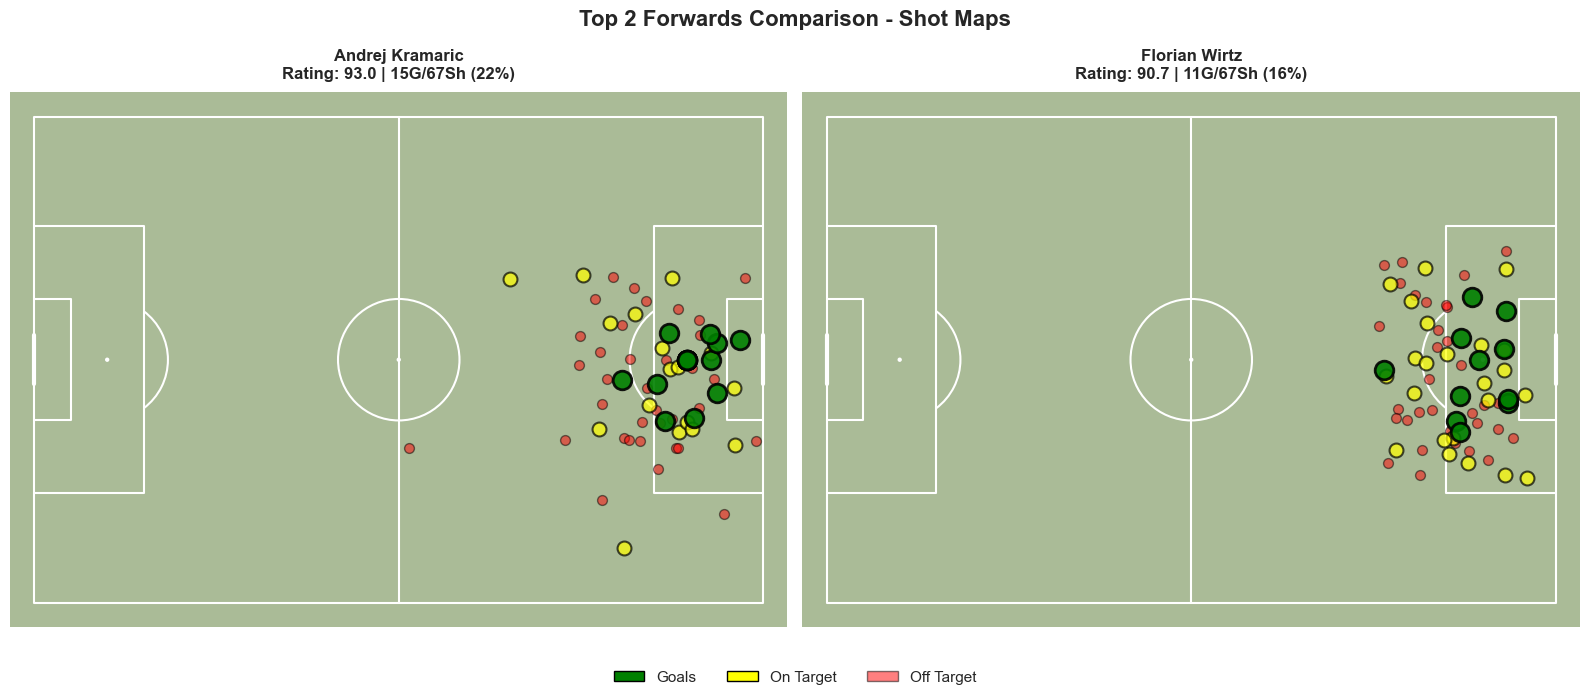


Saved: /Users/tanishbhilare/Desktop/SoccerImpectHackathon/figures/comparison_top_forwards.png
Forward comparison visualization created


In [19]:
# Cell: Create side-by-side player comparison

print("Creating side-by-side player comparison")

from mplsoccer import Pitch

# Get top 2 forwards for comparison
top_2_forwards = player_final.filter(
    pl.col('position') == 'forward'
).sort('overall_rating', descending=True).head(2)

if len(top_2_forwards) >= 2:
    player_1 = top_2_forwards[0:1]
    player_2 = top_2_forwards[1:2]
    
    name_1 = player_1['player_name'][0]
    name_2 = player_2['player_name'][0]
    
    print(f"\nComparing:")
    print(f"  {name_1}: {player_1['overall_rating'][0]:.1f} rating")
    print(f"  {name_2}: {player_2['overall_rating'][0]:.1f} rating")
    
    # Create side-by-side shot maps
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for idx, (player_data, ax) in enumerate(zip([player_1, player_2], axes)):
        player_id = player_data['player_id'][0]
        player_name = player_data['player_name'][0]
        
        # Create pitch
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                      line_color='white', linewidth=1.5)
        pitch.draw(ax=ax)
        
        # Get shots
        shots = all_events.filter(
            (pl.col('player_id') == player_id) &
            (pl.col('event_type') == 'SHOT') &
            (pl.col('coordinates_x').is_not_null()) &
            (pl.col('coordinates_y').is_not_null())
        )
        
        goals, saved, missed = [], [], []
        
        for row in shots.iter_rows(named=True):
            x = (row['coordinates_x'] + 52.5) * (120/105)
            y = (row['coordinates_y'] + 34) * (80/68)
            
            if row['result'] == 'GOAL':
                goals.append((x, y))
            elif row['result'] == 'SAVED':
                saved.append((x, y))
            else:
                missed.append((x, y))
        
        # Plot
        if goals:
            pitch.scatter([g[0] for g in goals], [g[1] for g in goals],
                         s=180, color='green', edgecolors='black', linewidth=2,
                         ax=ax, zorder=3, alpha=0.9)
        
        if saved:
            pitch.scatter([s[0] for s in saved], [s[1] for s in saved],
                         s=100, color='yellow', edgecolors='black', linewidth=1.5,
                         ax=ax, zorder=2, alpha=0.7)
        
        if missed:
            pitch.scatter([m[0] for m in missed], [m[1] for m in missed],
                         s=50, color='red', edgecolors='black', linewidth=1,
                         ax=ax, zorder=1, alpha=0.5)
        
        # Title
        overall = player_data['overall_rating'][0]
        conversion = len(goals) / len(shots) * 100 if len(shots) > 0 else 0
        
        ax.set_title(f'{player_name}\n'
                     f'Rating: {overall:.1f} | {len(goals)}G/{len(shots)}Sh ({conversion:.0f}%)',
                     fontsize=12, fontweight='bold', pad=10)
    
    # Overall title
    fig.suptitle('Top 2 Forwards Comparison - Shot Maps',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Shared legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', edgecolor='black', label='Goals'),
        Patch(facecolor='yellow', edgecolor='black', label='On Target'),
        Patch(facecolor='red', edgecolor='black', alpha=0.5, label='Off Target')
    ]
    fig.legend(handles=legend_elements, loc='lower center', 
               fontsize=11, ncol=3, framealpha=0.95)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    
    filepath = FIGURES_DIR / 'comparison_top_forwards.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved: {filepath}")
    print("Forward comparison visualization created")
else:
    print("Insufficient data for comparison")